###### CP model
$$
\begin{aligned}
\text{s.t.} \quad & 1 \le x_{ij} \le n^2 && \forall i \in I, \; j \in J \\
& \text{AllDifferent}( \{ x_{ij} \mid i \in I, \; j \in J \} ) \\
& \sum_{j \in J} x_{ij} = M && \forall i \in I \\
& \sum_{i \in I} x_{ij} = M && \forall j \in J \\
& \sum_{i=1}^n x_{ii} = M \\
& \sum_{i=1}^n x_{i,n+1-i} = M
\end{aligned}
$$

---

- $I = \{1, \dots, n\}$: set of rows
- $J = \{1, \dots, n\}$: set of columns
- $x_{ij}$: value placed in cell $(i, j)$

> **Note:** ILP does not have a direct `AllDifferent` constraint.  
> In ILP we should replace it with binary variables $y_{i,j,k}$:  
> $y_{i,j,k} = 1$ if value $k$ is assigned to cell $(i,j)$  
>  
> 1. Each cell gets exactly one value:  
>    $$\sum_{k} y_{i,j,k} = 1$$  
>  
> 2. Each value is used exactly once:  
>    $$\sum_{i} \sum_{j} y_{i,j,k} = 1$$  
>  
> 3. Link $y$ to the cell value:  
>    $$x_{i,j} = \sum_{k} k \cdot y_{i,j,k}$$

In [1]:
n = 3
M = (((n**2)*(n**2+1)) // 2) // n

In [2]:
from ortools.sat.python import cp_model

In [3]:
model = cp_model.CpModel()

In [4]:
x = {}
for i in range(n):
    for j in range(n):
        x[i,j] = model.NewIntVar(1, n*n, f"x[{i},{j}]")

In [5]:
model.AddAllDifferent(
    [x[i,j] for i in range(n) for j in range(n)]
)

for i in range(n):
    model.Add(sum( x[i,j] for j in range(n) ) == M ) 
    
for j in range(n):
    model.Add(sum(x[i,j] for i in range(n)) == M)
    
model.Add(sum(x[i,i] for i in range(n)) == M)
model.Add(sum(x[i,n-1-i] for i in range(n)) == M)

In [6]:
solver = cp_model.CpSolver()
results = solver.Solve(model)

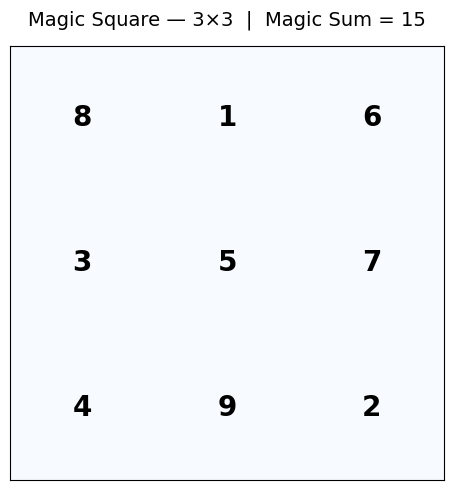

In [7]:
# copy paste this part from ai
import matplotlib.pyplot as plt

grid = [[solver.Value(x[i, j]) for j in range(n)] for i in range(n)]

fig, ax = plt.subplots(figsize=(5, 5))

ax.imshow([[1] * n for _ in range(n)], cmap="Blues")

for i in range(n):
    for j in range(n):
        ax.text(
            j, i, grid[i][j],
            ha="center",
            va="center",
            fontsize=20,
            fontweight="bold"
        )

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([])
ax.set_yticklabels([])

ax.set_title(
    f"Magic Square — {n}×{n}  |  Magic Sum = {M}",
    fontsize=14,
    pad=15
)

ax.tick_params(length=0)
plt.tight_layout()
plt.show()